# Dataset info 
- Load libraries 
- Check the stats
- check missing values and datatypes 
- visualize missing values (Extra but Helpful)

In [94]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [95]:
df = sns.load_dataset('penguins')

In [96]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [97]:
#Get dataset stats
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [98]:
#Check datatypes 
df.dtypes

species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

In [99]:
print(f"Dataset shape{df.shape}\nDataset with {df.shape[0]} rows and {df.shape[1]}columns")

Dataset shape(344, 7)
Dataset with 344 rows and 7columns


In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [101]:
df.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

### variables description:
- species -- which specie a penguin belongs to
- island -- different island names
- bill_length_mm -- length of the bill/peek of a penguin in mm
- bill depth_mm -- depth of the bill/peek of a penguin in mm
- flipper_length_mm -- length of flippers of a penguin in mm
- body_mass_g -- Body mass of penguins
- sex -- gender of penguin male/female

In [102]:
#Check for missing values 
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

# Univariate Analysis
- in univitrate analysis we do two things mainly:
1) Plot the categorical columns and plots we use to do it are mainly two (Count and bar plot)
2) Plot the Numerical columns and plots we use to do it are mainly two (histplot and boxplot and sometime KDE)
- Note that we do not plot these two (Categorical and numerical with each other we will do it in further steps (**Bivariate analysis**)

In [103]:
df.dtypes #We're using it so we can see which columns are categorical and numerical (Object=>categorical, float/int=>numerical)

species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

### Categorical columns plotting 

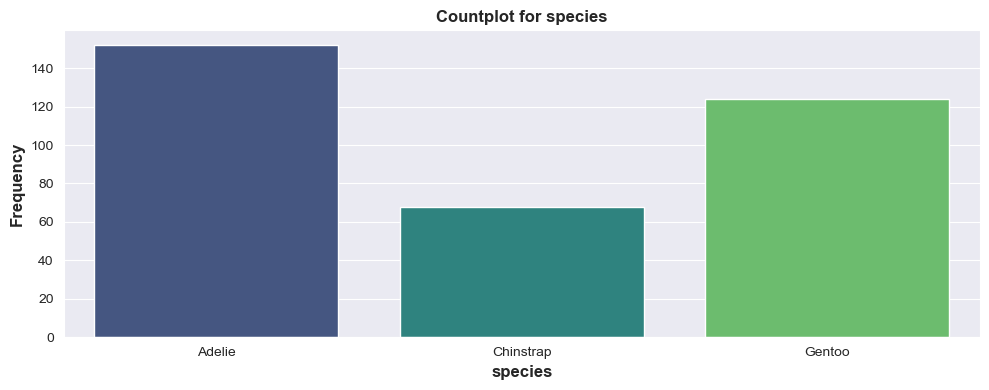

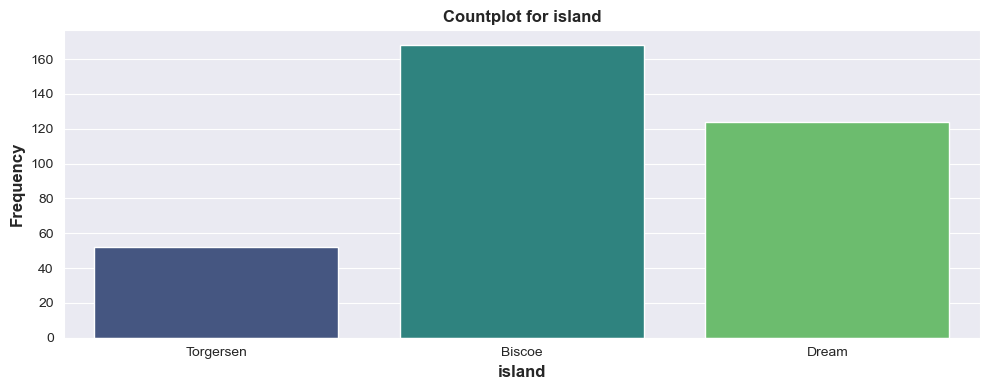

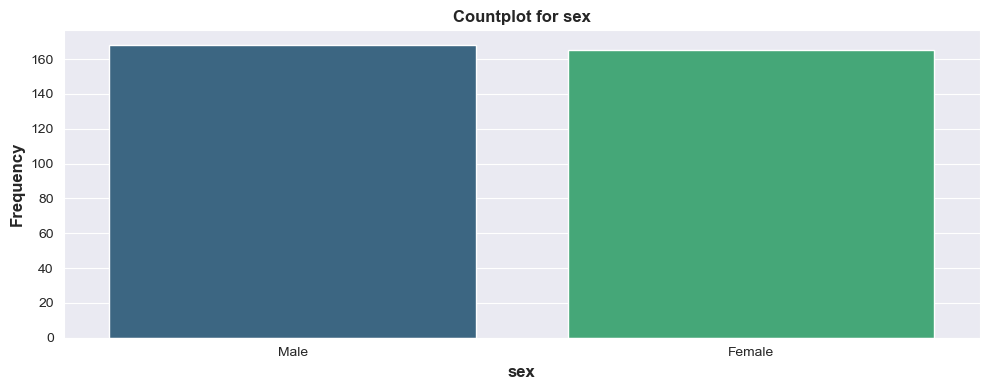

In [104]:
def Categorical_plotting(var): 
    sns.set_style('darkgrid')
    plt.figure(figsize=(10,4))
    sns.countplot(data=df, x=var, palette='viridis' ,legend=False,hue=var)
    plt.title(f"Countplot for {var}",fontsize=12,fontweight='bold')
    plt.xlabel(var,fontsize=12,fontweight='bold')
    plt.ylabel("Frequency",fontsize=12,fontweight='bold')
    plt.tight_layout()

columns = ['species','island','sex']
for c in columns:
    Categorical_plotting(c)

### `species`
- Most penguins belong to the **Adelie** species.
- **Chinstrap** and **Gentoo** are present in smaller, similar counts.
- No missing values observed.

---

### `island`
- **Biscoe** is the most frequent island.
- **Dream** and **Torgersen** have fewer observations.
- Slight imbalance but acceptable.

---

### `sex`
- **Some missing values** present (`NaN`).
- Among known values, **male and female counts are fairly balanced**.

---

### Numerical columns plotting 

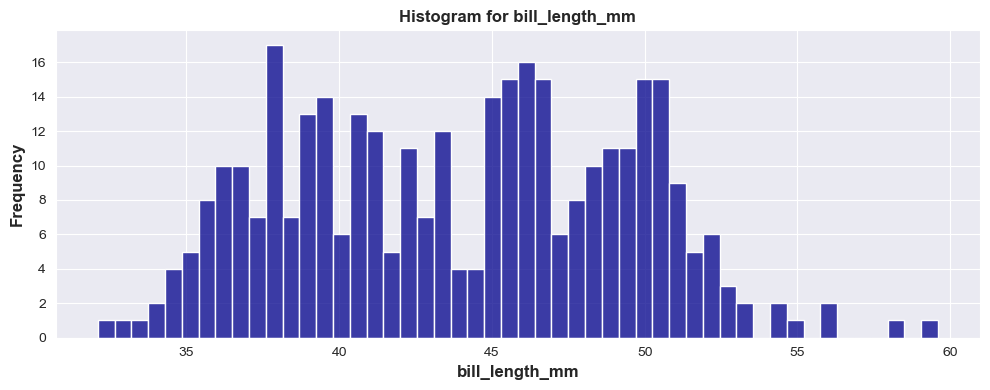

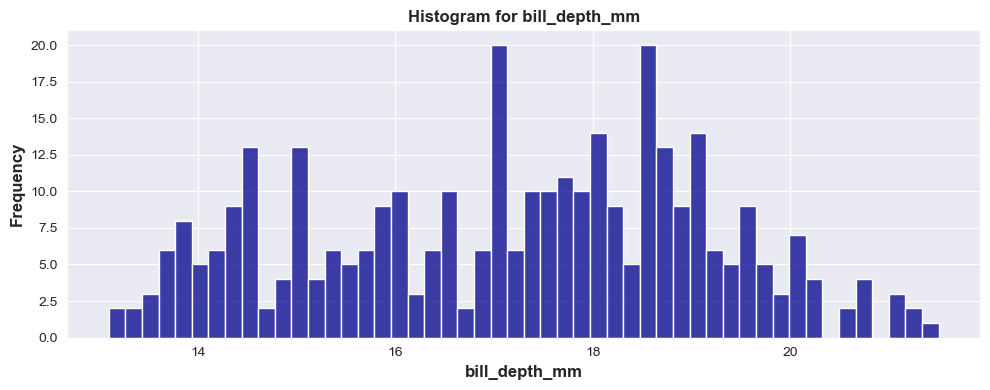

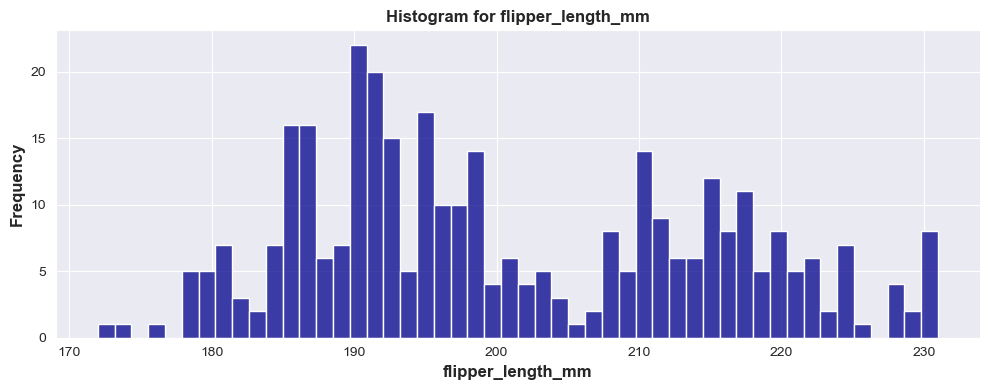

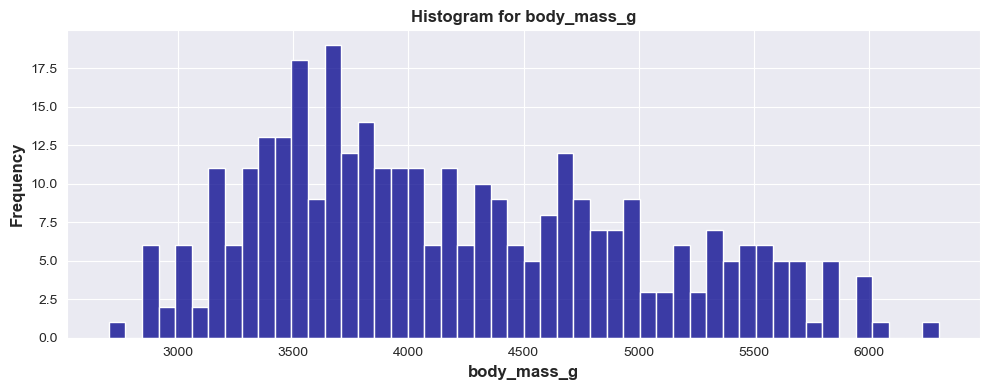

In [105]:
def Numerical_plotting(val):
    sns.set_style('darkgrid')
    plt.figure(figsize=(10,4))
    sns.histplot(df[val], bins=50, color='darkblue')
    plt.title(f"Histogram for {val}",fontsize=12,fontweight='bold')
    plt.xlabel(val,fontsize=12,fontweight='bold')
    plt.ylabel("Frequency",fontsize=12,fontweight='bold')
    plt.tight_layout()

columns = ['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']
for n in columns:
    Numerical_plotting(n)

## Univariate Analysis — Numerical Features (Penguins Dataset)

This section covers distributional analysis of key numerical features using histograms.  
For each feature, we analyzed the shape, central tendency, spread, and presence of potential outliers.

---

### `bill_length_mm`
- Shape: **Approximately symmetric**
- Most values lie between **35 and 50 mm**
- Values **above 55 mm** may be considered outliers

---

### `bill_depth_mm`
- Shape: **Slightly right-skewed**
- Most values fall between **17 and 19 mm**
- **Values below 15 mm** could be outliers

---

### `flipper_length_mm`
- Shape: **Multi-modal** (due to species variation)
- Main values lie between **180 and 230 mm**
- **Values above 230 mm** are rare but species-dependent — not necessarily outliers

---

### `body_mass_g`
- Shape: **Slightly right-skewed**
- Most penguins weigh between **3500g and 4500g**
- **Values above 6000g** may be considered outliers

---

> each plot was generated using `sns.histplot()` with `bins=50`, and observations were made based on visual interpretation.



# Basic data analysis using grouping and handling outliers

## Box plot to Visualize outliers
- `if outliers found`:
- Group, write conclusion and handle in the end  
- `if no outliers found`:
- just group the columns

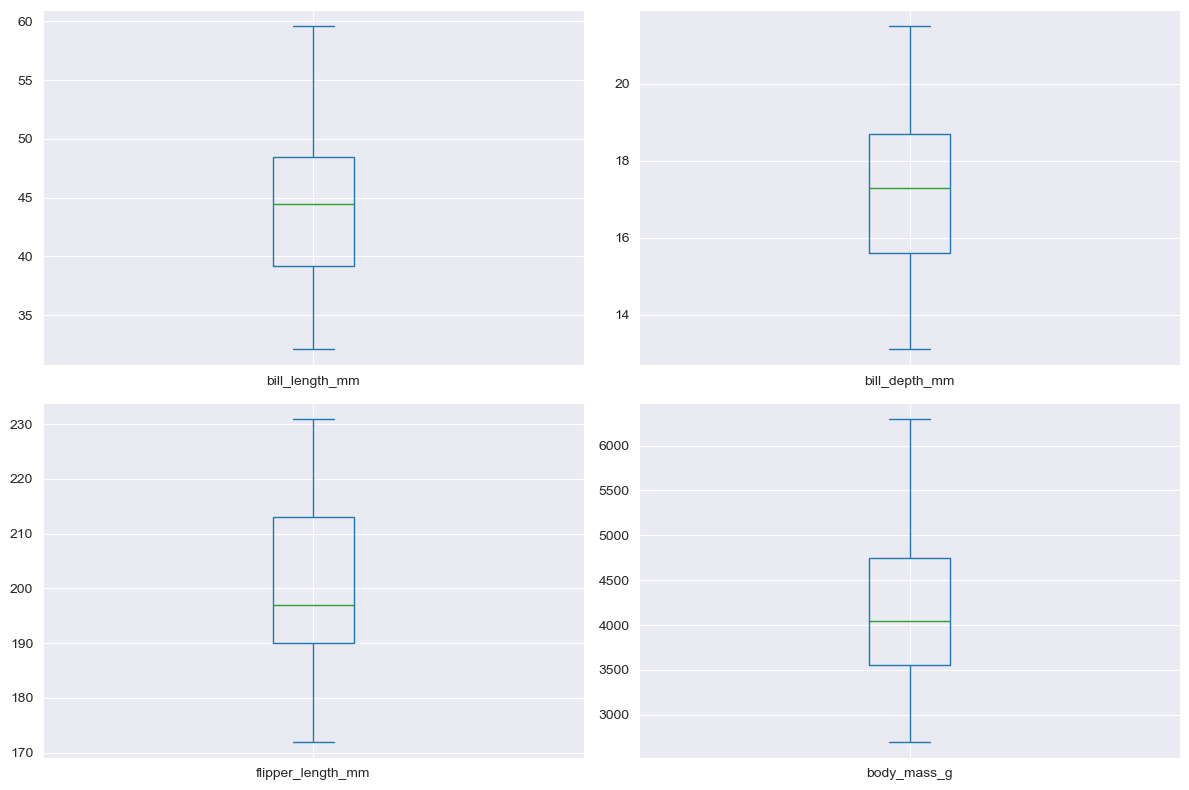

In [106]:
# Box plot 
num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
df[num_cols].plot(kind='box', subplots=True, layout=(2,2), figsize=(12,8), sharex=False)
plt.tight_layout()
plt.show()

All four columns looks clean no outliers detected, now we move to next step **Grouping columns**.

In [107]:
df.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

## Grouping:
1) species -- island	
2) species -- sex	
3) species -- all numerical cols	
4) island -- body_mass_g	

In [108]:
df.groupby('species')['island'].value_counts().reset_index()

,species,island,count
0,Adelie,Dream,56
1,Adelie,Torgersen,52
2,Adelie,Biscoe,44
3,Chinstrap,Dream,68
4,Gentoo,Biscoe,124


In [109]:
df.groupby('species')['sex'].value_counts().reset_index()

,species,sex,count
0,Adelie,Female,73
1,Adelie,Male,73
2,Chinstrap,Female,34
3,Chinstrap,Male,34
4,Gentoo,Male,61
5,Gentoo,Female,58


In [110]:
df.groupby('species')[['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']].agg(['mean','median']).reset_index()

species bill_length_mm        bill_depth_mm        flipper_length_mm  \
                       mean median          mean median              mean   
0     Adelie      38.791391  38.80     18.346358  18.40        189.953642   
1  Chinstrap      48.833824  49.55     18.420588  18.45        195.823529   
2     Gentoo      47.504878  47.30     14.982114  15.00        217.186992   

          body_mass_g          
  median         mean  median  
0  190.0  3700.662252  3700.0  
1  196.0  3733.088235  3700.0  
2  216.0  5076.016260  5000.0

concluding this we can see the **mean** and **median** of the numerical columns are almost same and that is why no outliers exist

In [111]:
df.groupby(['island','species'])['body_mass_g'].agg(['mean','median','max','min'])

mean  median     max     min
island    species                                       
Biscoe    Adelie     3709.659091  3750.0  4775.0  2850.0
          Gentoo     5076.016260  5000.0  6300.0  3950.0
Dream     Adelie     3688.392857  3575.0  4650.0  2900.0
          Chinstrap  3733.088235  3700.0  4800.0  2700.0
Torgersen Adelie     3706.372549  3700.0  4700.0  2900.0

`Grouped Insight`: Body Mass by Island & Species

- **Gentoo (Biscoe)** are the **heaviest** with the avg of **~5076g** and maxing at **6300g**.
- **Adelie** appear on all islands with a consistent avg. of **~3700g**.
- **Chinstrap (Dream)** also average around **3733g** but with a lower min (**2700g**).
- Mean ≈ Median in all groups → **no major outliers**.
- Gentoo's higher mean than median hints at **slightly skewed values**.

> Species affects body mass more than island location

### We've no outliers as per the stats so we move to next step

In [112]:
df.describe() # => No outliers detected 

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


# Handling Missing values
- Handle missing values using
  `Fillna`, `dropna`, `replace` etc.
- Enter mean/median in the numerical data
- Enter alphabetic keywords like "unknow","not-provided" etc. in the Categorical data
- if data makes no sense drop it

In [113]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [114]:
#Take out percentage of the missing values 
(df.isnull().mean()*100).sort_values(ascending=False)

sex                  3.197674
bill_length_mm       0.581395
bill_depth_mm        0.581395
flipper_length_mm    0.581395
body_mass_g          0.581395
species              0.000000
island               0.000000
dtype: float64

<Axes: >

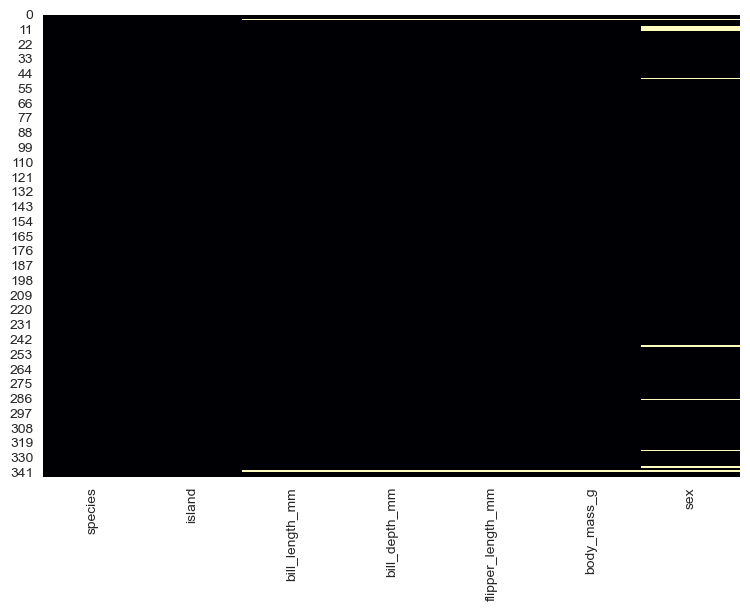

In [115]:
#Vislualize the missing values  
#visualize the missing values using a heatmap 
plt.figure(figsize=(9,6))
sns.heatmap(df.isnull(),cmap='magma',cbar=False)

In [116]:
def handling_n_columns(col):
    mean_val = df[col].mean()
    df[col] = df[col].fillna(mean_val)
    return 

n_columns = ['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']
for n in n_columns:
    handling_n_columns(n)

In [117]:
df['sex'] = df['sex'].fillna(df['sex'].mode()[0])
df['sex'].unique()

array(['Male', 'Female'], dtype=object)

In [118]:
df.isnull().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

# Visualziations (Bivariate)
in this step we'll do some more visualization like:
- drawing a `Heatmap` for all numerical value
- comparing cateogrical and numerical columns (Bivariate) the plots include, `countplot`,`catplot`,`Barplot`,`Boxplot`,`displot` and `Pairplot`

<Axes: >

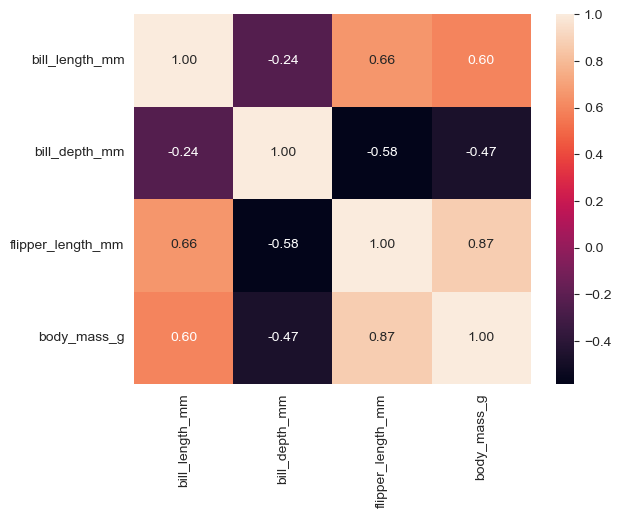

In [119]:
#Heatmap for numerical values 
n_columns = ['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']
sns.heatmap(data=df[n_columns].corr(),annot=True,fmt='.2f')

## Visualization 
- island -- species count
- species -- bill_length_mm
- species -- bill_depth
- species -- sex 
- gender -- body_mass_g
- **Correlation of Variables**
- bill_length_mm -- bill_depth_mm
- bill_length_mm -- flipper_length_mm
- bill_depth_mm -- flipper_length_mm
- Pairplot of all numerical values

### island -- species count

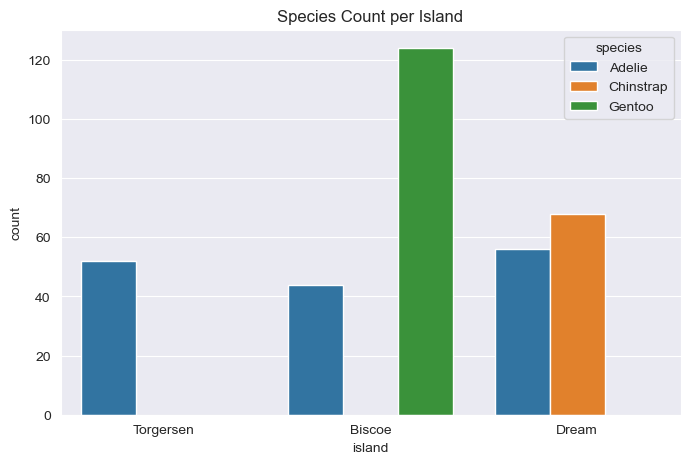

In [120]:
plt.figure(figsize=(8,5))
sns.set_style('darkgrid')
sns.countplot(data=df,x='island',hue='species')
plt.title("Species Count per Island")
plt.show()

### species -- bill_length_mm 

Bill Length Per species distribution


<Axes: xlabel='species', ylabel='bill_length_mm'>

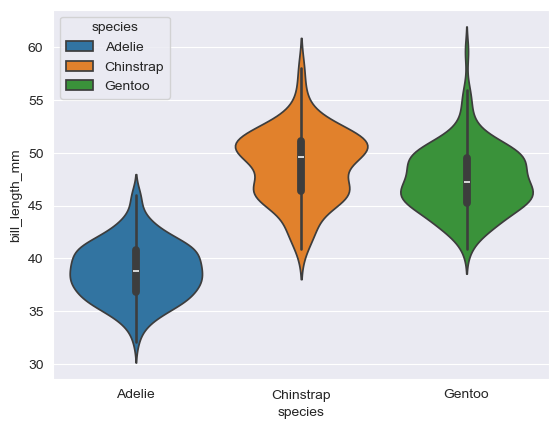

In [121]:
print("Bill Length Per species distribution")
sns.violinplot(data=df,x='species',y='bill_length_mm',hue='species',legend=True)

### species -- bill_depth_mm 

Bill Depth Per species distribution


<Axes: xlabel='species', ylabel='bill_depth_mm'>

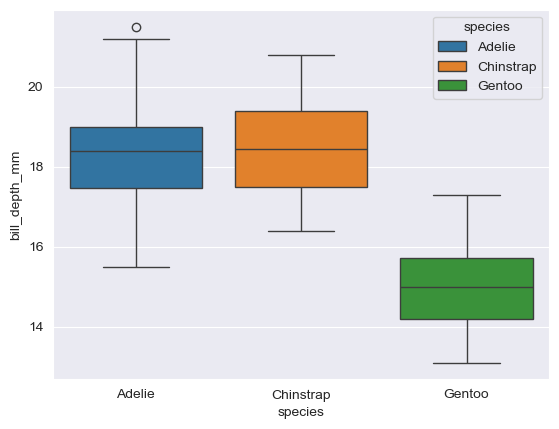

In [122]:
print("Bill Depth Per species distribution")
sns.boxplot(data=df,x='species',y='bill_depth_mm',hue='species',legend=True)

**Chinstrap** penguins have slightly more bill depth, while **Gentoo** penguins have the least.

### species -- sex

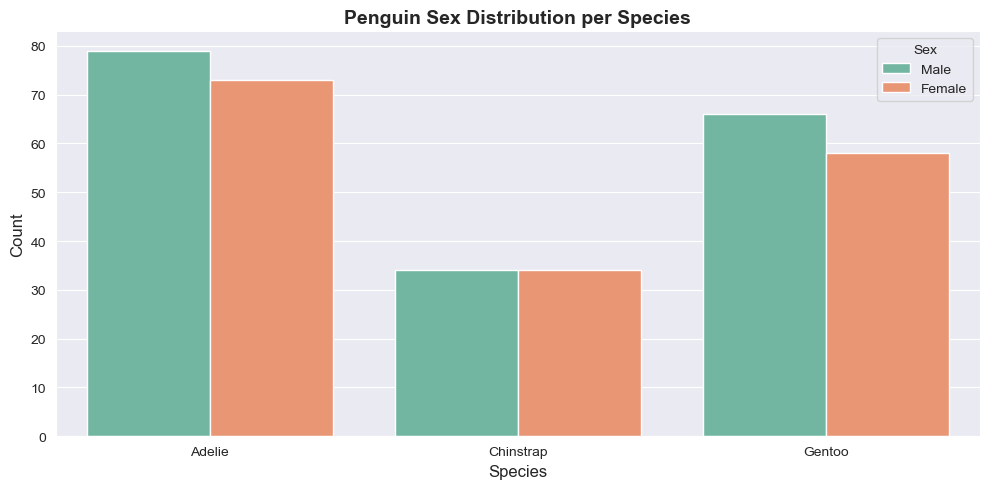

In [123]:
sns.set_style('darkgrid')
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='species', hue='sex', palette='Set2')
plt.title('Penguin Sex Distribution per Species', fontsize=14, fontweight='bold')
plt.xlabel('Species', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Sex')
plt.tight_layout()
plt.show()

### gender--body_mass_g

Text(0.5, 1.0, 'Gender on body mass')

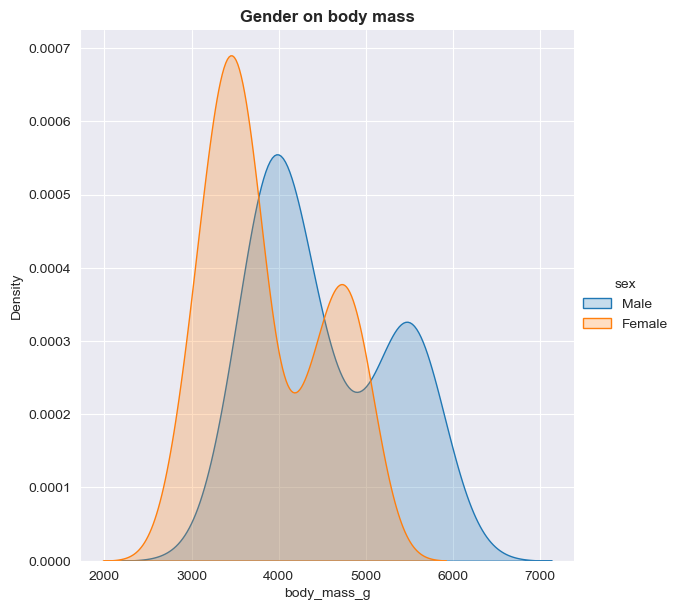

In [124]:
sns.FacetGrid(data=df, hue='sex',height=6).map(sns.kdeplot, 'body_mass_g',fill=True).add_legend()
plt.title("Gender on body mass",fontsize=12,fontweight='bold')

**Males** penguin has the higher body mass average than **female**

## Correaltion of variables
**Correlation measures the strength and direction of a linear relationship between two numerical variables.**

### bill_length_mm -- bill_depth_mm

Text(0.5, 1.0, 'Bill length Vs Bill depth')

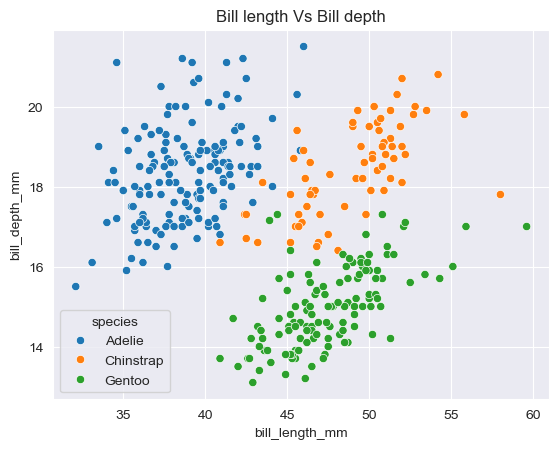

In [125]:
sns.scatterplot(df, x='bill_length_mm',y='bill_depth_mm',hue='species')
plt.title("Bill length Vs Bill depth")

**Adelie** penguins have the highest bill depth, while **Gentoo** and **Chinstrap** penguins have longer bill lengths, with **Chinstrap** showing high values in both measurements.

### bill_length_mm--flipper_length_mm

Text(0.5, 1.0, 'Bill length vs Flipper length')

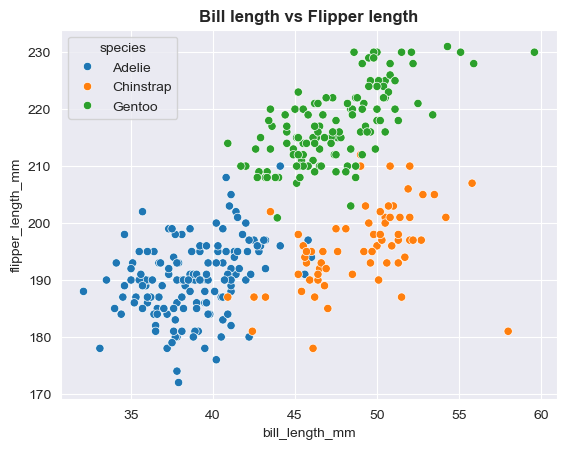

In [126]:
sns.scatterplot(df, x='bill_length_mm',y='flipper_length_mm',hue='species')
plt.title("Bill length vs Flipper length",fontsize=12,fontweight='bold')

**Gentoo** penguins have the longest flippers and high bill length. **Chinstrap** penguins have the highest bill length and above-average flipper length. **Adelie** penguins have the shortest bill and flipper length among all three species.

### bill_depth_mm -- flipper_length_mm

Text(0.5, 1.0, 'Bill depth vs Flipper length')

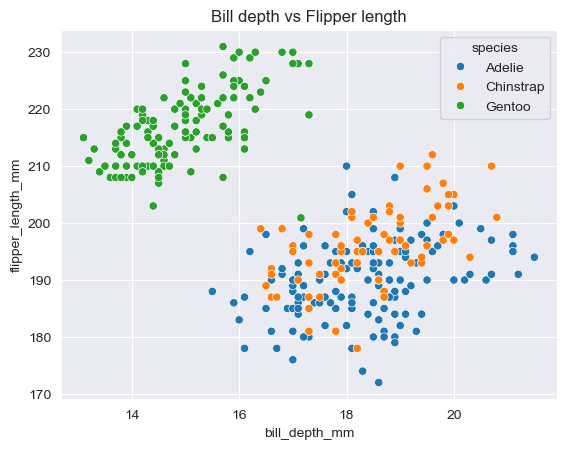

In [127]:
sns.scatterplot(df, x='bill_depth_mm', y='flipper_length_mm',hue='species')
plt.title("Bill depth vs Flipper length")

**Gentoo** penguins have the longest flippers and the shallowest bill depth. **Adelie** and **Chinstrap** penguins have shorter flippers and deeper bills compared to **Gentoo**.

### Pairplot

In [128]:
df.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

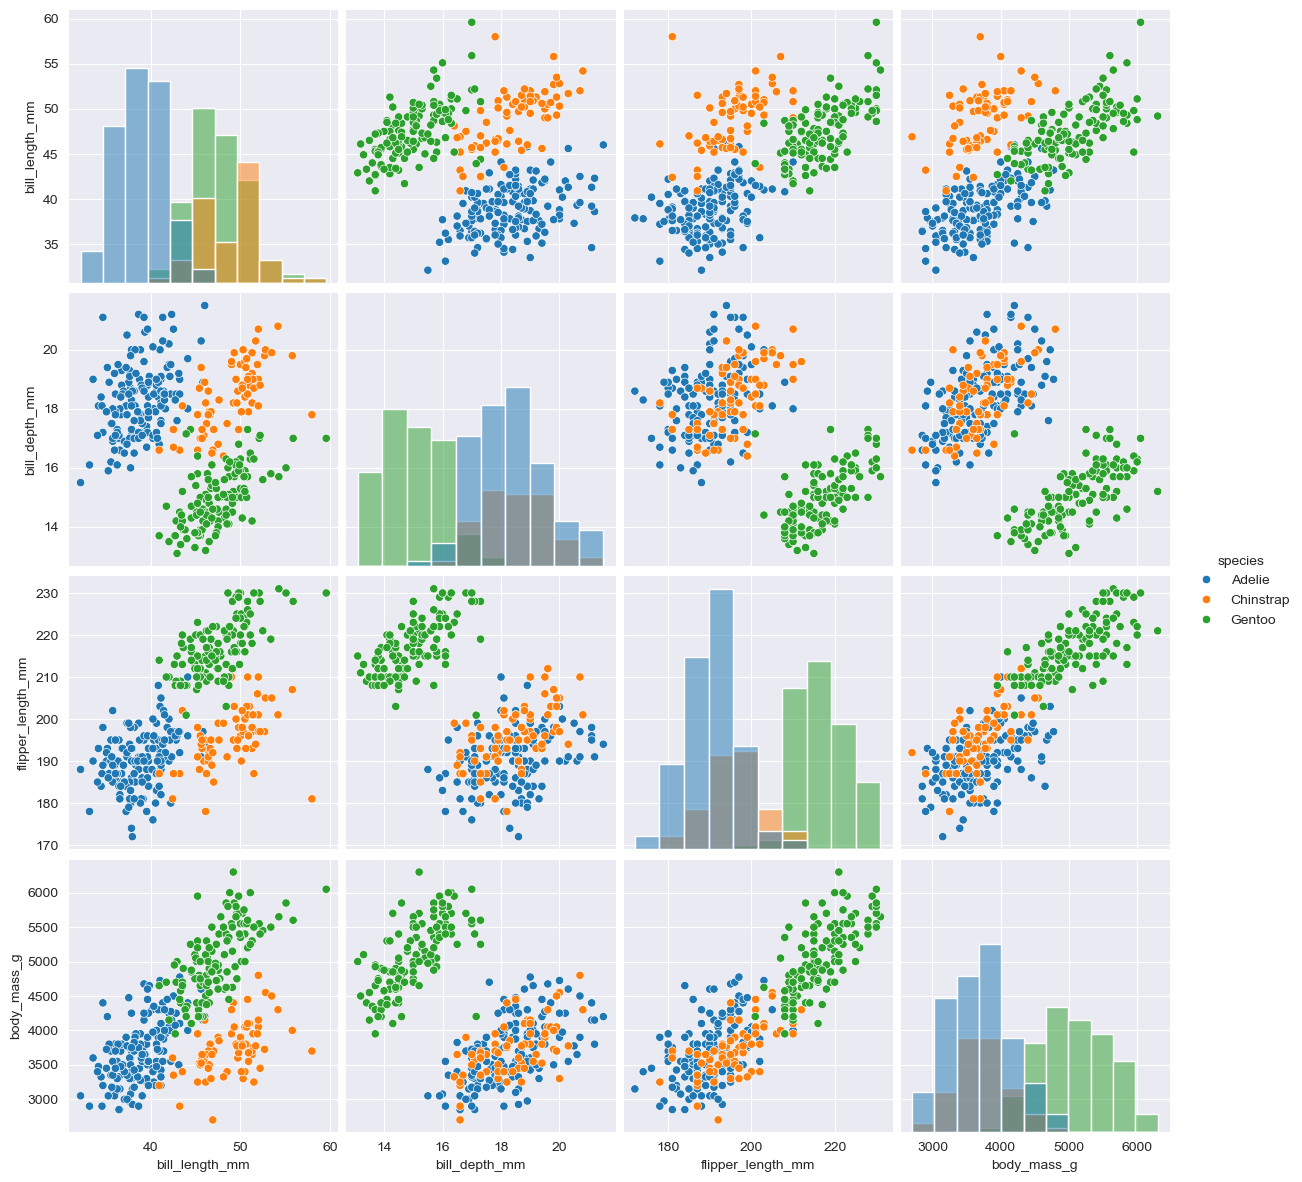

In [129]:
num_columns = ['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g','species']
sns.pairplot(data=df[num_columns], hue='species', height=3, diag_kind='hist')

# Feature Engineering

## Island (Nominal – 3 categories)
- **Technique:** One-Hot Encoding (`pd.get_dummies()`)

##  Species (Nominal – 3 categories)
- **Technique:** One-Hot Encoding

##  Sex (Binary)
- **Technique:** Label Encoding (Male → 0, Female → 1)

##  Numerical Feature Engineering
- **Goal:** Create additional meaningful features using existing numerical columns
- **Planned Ideas:**
  - **Bill Ratio** = bill_length_mm / bill_depth_mm
  - **Flipper-to-Mass Ratio** = flipper_length_mm / body_mass_g
  - **Size Class** = Classify penguins as "Small", "Medium", "Large" based on body_mass_g (optional)
  - **Interaction Features** if meaningful patterns are observed

In [130]:
#island & species 
df_dummies = pd.get_dummies(df[['species', 'island']], dtype=int)
df = pd.concat([df, df_dummies], axis=1)

In [131]:
#sex  
df['Gender_ecoding'] = df['sex'].map({'Male':1, 'Female':0})

In [132]:
#Numerical 1
df['bill_ratio'] = df['bill_length_mm'] / df['bill_depth_mm']

In [133]:
#Numerical 2
df['Flipper-to-Mass Ratio'] = df['flipper_length_mm'] / df['body_mass_g']

In [134]:
#Numerical 3 
bin = [0,3550,4750,df['body_mass_g'].max()]
label = ['small', 'medium','large']

df['size_class'] = pd.cut(df['body_mass_g'],
                          bins=bin,
                          labels=label,
                          right=False)

In [135]:
#Final df
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,species_Adelie,species_Chinstrap,species_Gentoo,island_Biscoe,island_Dream,island_Torgersen,Gender_ecoding,bill_ratio,Flipper-to-Mass Ratio,size_class
0,Adelie,Torgersen,39.10000,18.70000,181.000000,3750.000000,Male,1,0,0,0,0,1,1,2.090909,0.048267,medium
1,Adelie,Torgersen,39.50000,17.40000,186.000000,3800.000000,Female,1,0,0,0,0,1,0,2.270115,0.048947,medium
2,Adelie,Torgersen,40.30000,18.00000,195.000000,3250.000000,Female,1,0,0,0,0,1,0,2.238889,0.060000,small
3,Adelie,Torgersen,43.92193,17.15117,200.915205,4201.754386,Male,1,0,0,0,0,1,1,2.560871,0.047817,medium
4,Adelie,Torgersen,36.70000,19.30000,193.000000,3450.000000,Female,1,0,0,0,0,1,0,1.901554,0.055942,small
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,43.92193,17.15117,200.915205,4201.754386,Male,0,0,1,1,0,0,1,2.560871,0.047817,medium
340,Gentoo,Biscoe,46.80000,14.30000,215.000000,4850.000000,Female,0,0,1,1,0,0,0,3.272727,0.044330,large
341,Gentoo,Biscoe,50.40000,15.70000,222.000000,5750.000000,Male,0,0,1,1,0,0,1,3.210191,0.038609,large
342,Gentoo,Biscoe,45.20000,14.80000,212.000000,5200.000000,Female,0,0,1,1,0,0,0,3.054054,0.040769,large


# Final visualizations on Feature Engineered Columns 

to be covered tomorrow...